## Установка библиотек

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os
import random
import glob
import traceback
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
import os
import matplotlib.pyplot as plt
import traceback
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image

## Проверка видеокарты

In [4]:
print("=" * 60)
print("ПРОВЕРКА СИСТЕМЫ И ВИДЕОКАРТЫ")
print("=" * 60)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
print(f"Number of CUDA devices: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
else:
    print("CUDA не доступна!")
    
    try:
        nvidia_smi = subprocess.check_output(["nvidia-smi"], shell=True).decode()
        print("NVIDIA драйверы установлены, но PyTorch не видит GPU")
    except:
        print("NVIDIA драйверы не установлены или nvidia-smi не доступен")


if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nИспользуется GPU: {torch.cuda.get_device_name()}")
else:
    device = torch.device("cpu")
    print(f"\nИспользуется CPU")

print(f"Selected device: {device}")

ПРОВЕРКА СИСТЕМЫ И ВИДЕОКАРТЫ
PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
Number of CUDA devices: 1
GPU 0: NVIDIA GeForce RTX 3060 Laptop GPU
  Memory: 6.0 GB

Используется GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Selected device: cuda


In [5]:
!nvidia-smi

Sun Nov  9 22:54:29 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 527.99       Driver Version: 527.99       CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   42C    P8    13W /  80W |    389MiB /  6144MiB |      6%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Обучение модели

Using device: cuda
MULTI-LABEL КЛАССИФИКАЦИЯ
Найдена папка: ../merged_augmented_data
Содержимое: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90', 'MY_data']

Используем путь: ../merged_augmented_data
Загрузка multi-label данных из: ../merged_augmented_data
Найдено 41170 изображений с 12 классами
Найдено классов: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90', 'MY_data']
Всего изображений: 41170
Тренировочные данные: 32936 изображений
Тестовые данные: 8234 изображений
Найдено 41170 изображений с 12 классами

ИНФОРМАЦИЯ О ДАННЫХ:
Classes: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90', 'MY_data']
Number of classes: 12
Training samples: 32936
Test samples: 8234

Sample batch - Images shape: torch.Size([16, 3, 224, 224])
Sample batch - Labels shape: torch.Size([16, 12])
Sample labels (first 3): tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
  

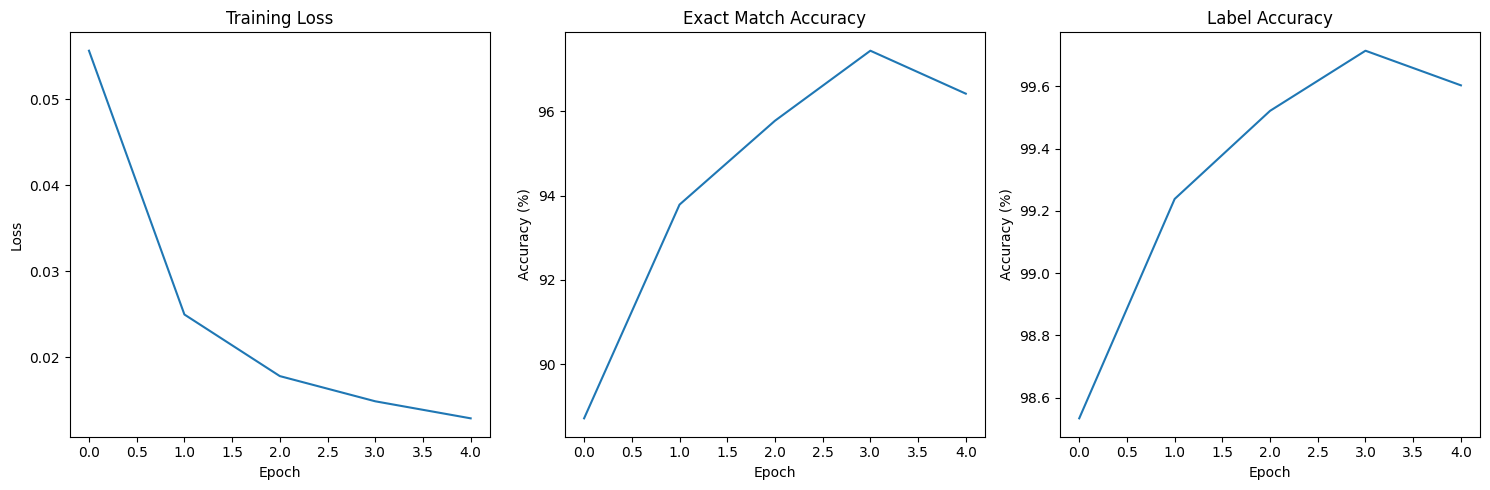

✅ Multi-label model saved!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultiLabelImageFolder(Dataset):
    """
    Кастомный Dataset для multi-label классификации
    Предполагает структуру папок, где каждый файл может принадлежать нескольким классам
    """
    def __init__(self, data_path, transform=None, label_file=None):
        self.data_path = data_path
        self.transform = transform
        
        self.image_paths = []
        self.labels = []
        self.classes = []
        
        if label_file and os.path.exists(label_file):
            self._load_from_csv(label_file)
        else:
            self._load_from_folders()
    
    def _load_from_folders(self):
        """Загрузка данных из структуры папок (multi-label)"""
        self.classes = sorted([d for d in os.listdir(self.data_path) 
                             if os.path.isdir(os.path.join(self.data_path, d))])
        
        class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        image_dict = {}
        
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_path, class_name)
            if not os.path.isdir(class_path):
                continue
                
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    
                    if img_path not in image_dict:
                        image_dict[img_path] = []
                    
                    image_dict[img_path].append(class_idx)
        
        self.image_paths = list(image_dict.keys())
        self.labels = [self._to_multi_hot(labels, len(self.classes)) 
                      for labels in image_dict.values()]
        
        print(f"Найдено {len(self.image_paths)} изображений с {len(self.classes)} классами")
    
    def _load_from_csv(self, label_file):
        """Загрузка данных из CSV файла с multi-label метками"""
        df = pd.read_csv(label_file)
        self.classes = [col for col in df.columns if col not in ['image', 'filename']]
        
        for _, row in df.iterrows():
            img_name = row['image'] if 'image' in row else row['filename']
            img_path = os.path.join(self.data_path, img_name)
            
            if os.path.exists(img_path):
                self.image_paths.append(img_path)
                labels = [int(row[cls]) for cls in self.classes]
                self.labels.append(labels)
    
    def _to_multi_hot(self, indices, num_classes):
        """Конвертирует список индексов в multi-hot вектор"""
        multi_hot = [0] * num_classes
        for idx in indices:
            if idx < num_classes:
                multi_hot[idx] = 1
        return multi_hot
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.float32)
        return image, label

def load_and_split_data(data_path, train_ratio=0.8, label_file=None):
    """
    Загружает данные для multi-label классификации и разделяет на выборки
    """
    print(f"Загрузка multi-label данных из: {data_path}")
    
    if not os.path.exists(data_path):
        print(f"Ошибка: Папка {data_path} не существует!")
        print("Содержимое текущей директории:")
        print(os.listdir('.'))
        return None, None, None
    
    full_dataset = MultiLabelImageFolder(
        data_path=data_path,
        transform=train_transform,
        label_file=label_file
    )
    
    print(f"Найдено классов: {full_dataset.classes}")
    print(f"Всего изображений: {len(full_dataset)}")
    
    train_size = int(train_ratio * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    print(f"Тренировочные данные: {train_size} изображений")
    print(f"Тестовые данные: {test_size} изображений")
    
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    
    test_dataset_full = MultiLabelImageFolder(
        data_path=data_path,
        transform=val_transform,
        label_file=label_file
    )
    test_dataset = torch.utils.data.Subset(test_dataset_full, test_dataset.indices)
    
    return train_dataset, test_dataset, full_dataset.classes

def create_resnet_model(num_classes, pretrained=True):
    """Создает модель ResNet для multi-label классификации"""
    model = models.resnet18(pretrained=pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

class MultiLabelLoss(nn.Module):
    """Loss функция для multi-label классификации"""
    def __init__(self):
        super(MultiLabelLoss, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss()
    
    def forward(self, outputs, targets):
        return self.bce_loss(outputs, targets)

def calculate_multi_label_accuracy(outputs, targets, threshold=0.5):
    """Вычисляет accuracy для multi-label классификации"""
    with torch.no_grad():
        preds = torch.sigmoid(outputs) > threshold
        correct = (preds == targets.bool()).float()
        
        exact_match = (correct.sum(dim=1) == targets.size(1)).float().mean()
        
        label_accuracy = correct.mean()
        
        return exact_match.item(), label_accuracy.item()

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=25):
    """Обучение для multi-label классификации"""
    model = model.to(device)
    train_losses = []
    val_exact_accuracies = []
    val_label_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        model.eval()
        total_exact_accuracy = 0.0
        total_label_accuracy = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                
                exact_acc, label_acc = calculate_multi_label_accuracy(outputs, labels)
                total_exact_accuracy += exact_acc
                total_label_accuracy += label_acc
                val_batches += 1
        
        epoch_loss = running_loss / len(train_loader)
        epoch_exact_accuracy = 100 * total_exact_accuracy / val_batches
        epoch_label_accuracy = 100 * total_label_accuracy / val_batches
        
        train_losses.append(epoch_loss)
        val_exact_accuracies.append(epoch_exact_accuracy)
        val_label_accuracies.append(epoch_label_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')
        print(f'Exact Match Accuracy: {epoch_exact_accuracy:.2f}%')
        print(f'Label Accuracy: {epoch_label_accuracy:.2f}%')
        print('-' * 50)
    
    return train_losses, val_exact_accuracies, val_label_accuracies

def check_data_structure():
    """Проверяет существование различных возможных путей"""
    possible_paths = [
        "../merged_augmented_data",
        "merged_augmented_data", 
        "./merged_augmented_data"
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Найдена папка: {path}")
            print(f"Содержимое: {os.listdir(path)}")
            return path
        else:
            print(f"Папка не найдена: {path}")
    
    return None

if __name__ == "__main__":
    print("=" * 60)
    print("MULTI-LABEL КЛАССИФИКАЦИЯ")
    print("=" * 60)
    
    data_path = check_data_structure()
    
    if data_path is None:
        print("\nНе удалось найти папку с данными!")
        exit()
    
    print(f"\nИспользуем путь: {data_path}")
    
    try:
        train_dataset, test_dataset, class_names = load_and_split_data(data_path, train_ratio=0.8)
        
        if train_dataset is None:
            exit()
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
        print(f"Classes: {class_names}")
        print(f"Number of classes: {len(class_names)}")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        sample_images, sample_labels = next(iter(train_loader))
        print(f"\nSample batch - Images shape: {sample_images.shape}")
        print(f"Sample batch - Labels shape: {sample_labels.shape}")
        print(f"Sample labels (first 3): {sample_labels[:3]}")
        
        num_classes = len(class_names)
        model = create_resnet_model(num_classes, pretrained=True)
        
        criterion = MultiLabelLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        print(f"\nНАЧАЛО ОБУЧЕНИЯ MULTI-LABEL МОДЕЛИ")
        print("=" * 60)
        
        train_losses, val_exact_acc, val_label_acc = train_model(
            model, train_loader, test_loader, criterion, optimizer, epochs=5
        )
        
        if len(train_losses) > 0:
            plt.figure(figsize=(15, 5))
            
            plt.subplot(1, 3, 1)
            plt.plot(train_losses)
            plt.title('Training Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            
            plt.subplot(1, 3, 2)
            plt.plot(val_exact_acc)
            plt.title('Exact Match Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy (%)')
            
            plt.subplot(1, 3, 3)
            plt.plot(val_label_acc)
            plt.title('Label Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy (%)')
            
            plt.tight_layout()
            plt.show()
            
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'model_architecture': 'resnet18',
                'multi_label': True
            }, 'phone_fast_created_merged_data_resnet18_multilabel.pth')
            
            print("✅ Multi-label model saved!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        traceback.print_exc()

Архитектура модели: resnet18
Количество классов: 11
Multi-label режим: True
Модель успешно загружена с cuda
Multi-label модель загружена для тестирования
Классы модели: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']

ЗАПУСК MULTI-LABEL ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ
Поиск изображений в данных...
Поиск в папке: 110
Поиск в папке: 130
Поиск в папке: 150
Поиск в папке: 170
Поиск в папке: 190
Поиск в папке: 210
Поиск в папке: 230
Поиск в папке: 250
Поиск в папке: 50
Поиск в папке: 70
Поиск в папке: 90
Найдено всего изображений: 221

Начинаем предсказание для 20 изображений...

Изображение 1/20
Файл: IMG_20251002_200016.jpg
Истинные классы: 170
Предсказанные классы: 170
Уверенность: 81.09%
Точность по меткам: 100.0%
Результат: ✅ ТОЧНОЕ СОВПАДЕНИЕ

Изображение 2/20
Файл: IMG_20251002_185252_2.jpg
Истинные классы: 70
Предсказанные классы: 70
Уверенность: 99.86%
Точность по меткам: 100.0%
Результат: ✅ ТОЧНОЕ СОВПАДЕНИЕ

Изображение 3/20
Файл: IMG_20251002_191443.jp

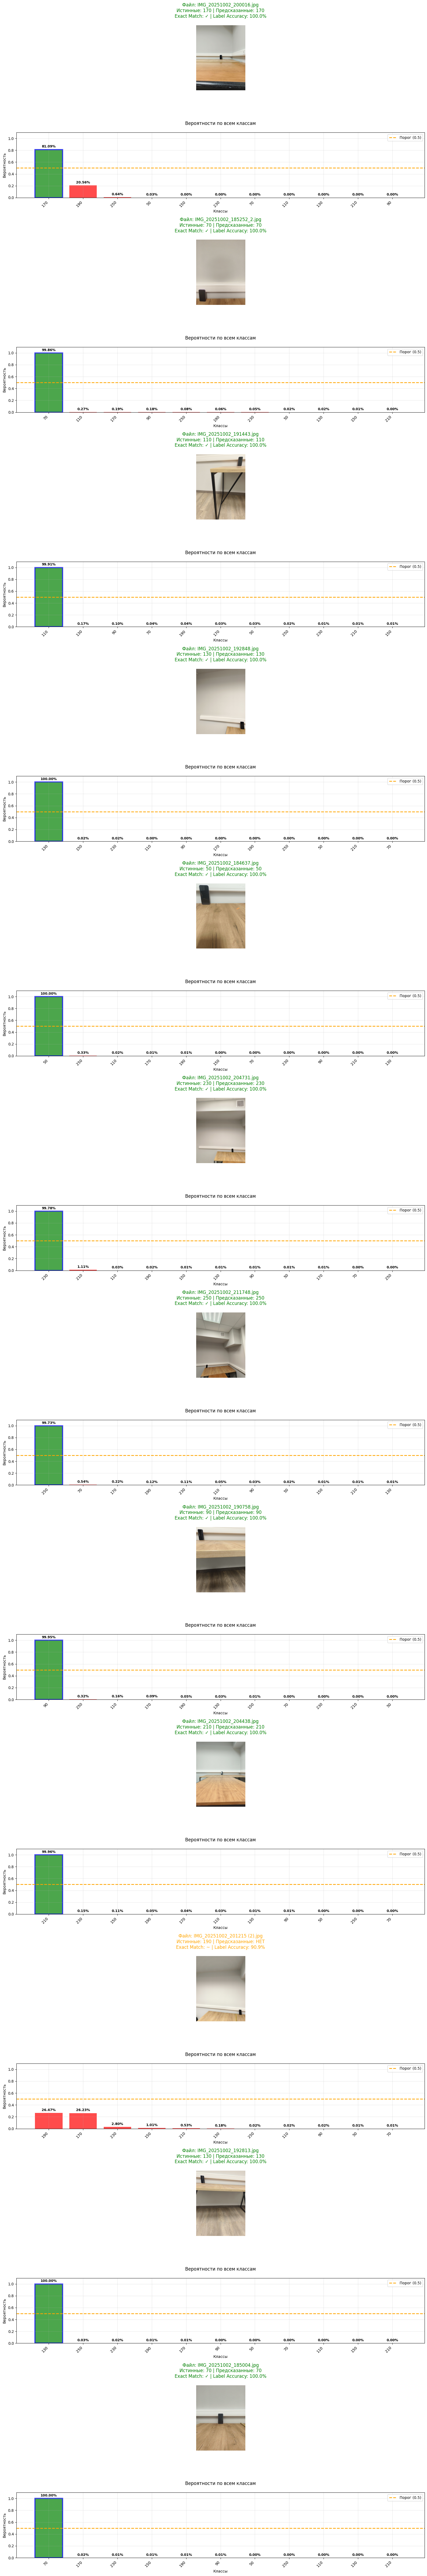

In [ ]:
def load_trained_model(model_path, num_classes=None, device='cpu', multi_label=True):
    """
    Загружает обученную модель для multi-label классификации
    
    Args:
        model_path: путь к файлу модели
        num_classes: количество классов (если None, будет определено автоматически)
        device: устройство для загрузки модели
        multi_label: флаг multi-label классификации
    
    Returns:
        model: загруженная модель
        class_names: список названий классов
    """
    try:
        checkpoint = torch.load(model_path, map_location=device)
        
        if 'class_names' in checkpoint:
            class_names = checkpoint['class_names']
            num_classes = len(class_names)
        else:
            print("class_names не найдены в чекпоинте")
            class_names = None
        
        if 'model_architecture' in checkpoint:
            arch = checkpoint['model_architecture']
        else:
            arch = 'resnet18'
        
        is_multi_label = checkpoint.get('multi_label', multi_label)
        print(f"Архитектура модели: {arch}")
        print(f"Количество классов: {num_classes}")
        print(f"Multi-label режим: {is_multi_label}")
        
        if arch == 'resnet18':
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif arch == 'resnet50':
            model = models.resnet50(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            raise ValueError(f"Неизвестная архитектура: {arch}")
        
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        
        model.to(device)
        model.eval()
        
        print(f"Модель успешно загружена с {device}")
        
        return model, class_names, is_multi_label
        
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")
        raise

def predict_multiple_images(model, data_folder, class_names, device, num_images=20, 
                          transform=None, multi_label=True, threshold=0.5):
    """
    Предсказывает классы для нескольких изображений (multi-label)
    
    Args:
        model: обученная модель
        data_folder: путь к папке с данными
        class_names: список названий классов
        device: устройство для вычислений
        num_images: количество изображений для предсказания
        transform: трансформации для изображений
        multi_label: флаг multi-label классификации
        threshold: порог для бинарной классификации
    
    Returns:
        list: список результатов предсказаний
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    all_images = []
    image_true_labels = []
    
    print("Поиск изображений в данных...")
    
    for class_name in class_names:
        class_path = os.path.join(data_folder, class_name)
        if os.path.exists(class_path):
            print(f"Поиск в папке: {class_name}")
            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    full_path = os.path.join(class_path, file)
                    
                    true_labels = [0] * len(class_names)
                    class_idx = class_names.index(class_name)
                    true_labels[class_idx] = 1
                    
                    if full_path in all_images:
                        idx = all_images.index(full_path)
                        image_true_labels[idx][class_idx] = 1
                    else:
                        all_images.append(full_path)
                        image_true_labels.append(true_labels)
    
    print(f"Найдено всего изображений: {len(all_images)}")
    
    if len(all_images) == 0:
        print("Не найдено изображений!")
        return []
    
    if len(all_images) < num_images:
        selected_indices = range(len(all_images))
        print(f"Найдено только {len(all_images)} изображений, будем использовать все")
    else:
        selected_indices = random.sample(range(len(all_images)), num_images)
    
    results = []
    
    print(f"\nНачинаем предсказание для {len(selected_indices)} изображений...")
    print("=" * 80)
    
    for i, idx in enumerate(selected_indices):
        image_path = all_images[idx]
        true_labels = image_true_labels[idx]
        
        print(f"\nИзображение {i+1}/{len(selected_indices)}")
        print(f"Файл: {os.path.basename(image_path)}")
        
        true_classes = [class_names[j] for j, label in enumerate(true_labels) if label == 1]
        print(f"Истинные классы: {', '.join(true_classes)}")
        
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            model.eval()
            with torch.no_grad():
                outputs = model(image_tensor)
                
                if multi_label:
                    probabilities = torch.sigmoid(outputs)
                    predicted_probs = probabilities.cpu().numpy()[0]
                    
                    predicted_labels = (predicted_probs > threshold).astype(int)
                    predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
                    
                    if predicted_classes:
                        confidence = np.mean([predicted_probs[j] for j, pred in enumerate(predicted_labels) if pred == 1])
                    else:
                        confidence = 0.0
                        
                else:
                    probabilities = torch.nn.functional.softmax(outputs, dim=1)
                    predicted_prob, predicted_class = torch.max(probabilities, 1)
                    predicted_classes = [class_names[predicted_class.item()]]
                    confidence = predicted_prob.item()
                    predicted_labels = [0] * len(class_names)
                    predicted_labels[predicted_class.item()] = 1
            
            if multi_label:
                is_exact_match = all(pred == true for pred, true in zip(predicted_labels, true_labels))
                correct_labels = sum(pred == true for pred, true in zip(predicted_labels, true_labels))
                label_accuracy = correct_labels / len(class_names)
                
                result = {
                    'image_path': image_path,
                    'true_labels': true_labels,
                    'true_classes': true_classes,
                    'predicted_labels': predicted_labels,
                    'predicted_classes': predicted_classes,
                    'predicted_probs': predicted_probs if multi_label else None,
                    'confidence': confidence,
                    'is_exact_match': is_exact_match,
                    'label_accuracy': label_accuracy,
                    'multi_label': multi_label
                }
            else:
                is_correct = (predicted_classes[0] in true_classes)
                result = {
                    'image_path': image_path,
                    'true_labels': true_labels,
                    'true_classes': true_classes,
                    'predicted_labels': predicted_labels,
                    'predicted_classes': predicted_classes,
                    'confidence': confidence,
                    'is_correct': is_correct,
                    'multi_label': multi_label
                }
            
            results.append(result)
            
            if multi_label:
                status = "✅ ТОЧНОЕ СОВПАДЕНИЕ" if is_exact_match else "⚠ ЧАСТИЧНОЕ СОВПАДЕНИЕ"
                print(f"Предсказанные классы: {', '.join(predicted_classes) if predicted_classes else 'НЕТ'}")
                print(f"Уверенность: {confidence:.2%}")
                print(f"Точность по меткам: {label_accuracy:.1%}")
                print(f"Результат: {status}")
            else:
                status = "✅ ПРАВИЛЬНО" if is_correct else "❌ ОШИБКА"
                print(f"Предсказанный класс: {predicted_classes[0]}")
                print(f"Уверенность: {confidence:.2%}")
                print(f"Результат: {status}")
            
        except Exception as e:
            print(f"Ошибка при обработке изображения: {e}")
            continue
    
    return results

def predict_image(model, image_path, class_names, device, transform=None, multi_label=True, threshold=0.5):
    """
    Предсказывает классы для одного изображения (multi-label)
    
    Args:
        model: обученная модель
        image_path: путь к изображению
        class_names: список названий классов
        device: устройство для вычислений
        transform: трансформации для изображений
        multi_label: флаг multi-label классификации
        threshold: порог для бинарной классификации
    
    Returns:
        dict: словарь с результатами предсказания
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    print(f"Предсказание для изображения: {image_path}")
    print(f"Multi-label режим: {multi_label}")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            
            if multi_label:
                probabilities = torch.sigmoid(outputs)
                predicted_probs = probabilities.cpu().numpy()[0]
                
                predicted_labels = (predicted_probs > threshold).astype(int)
                predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
                
                result = {
                    'image_path': image_path,
                    'predicted_labels': predicted_labels,
                    'predicted_classes': predicted_classes,
                    'predicted_probs': predicted_probs,
                    'class_probabilities': {
                        class_name: prob for class_name, prob in zip(class_names, predicted_probs)
                    },
                    'threshold': threshold,
                    'multi_label': multi_label
                }
                
                print(f"Предсказанные классы: {', '.join(predicted_classes) if predicted_classes else 'НЕТ'}")
                print(f"Порог: {threshold}")
                print("\nВероятности по всем классам:")
                for class_name, prob in zip(class_names, predicted_probs):
                    status = "✓" if prob > threshold else "✗"
                    print(f"   {class_name}: {prob:.2%} {status}")
                    
            else:
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                predicted_prob, predicted_class = torch.max(probabilities, 1)
                predicted_class_name = class_names[predicted_class.item()]
                
                all_probs = probabilities.cpu().numpy()[0]
                
                result = {
                    'image_path': image_path,
                    'predicted_class': predicted_class_name,
                    'confidence': predicted_prob.item(),
                    'all_probabilities': all_probs,
                    'class_probabilities': {
                        class_name: prob for class_name, prob in zip(class_names, all_probs)
                    },
                    'multi_label': multi_label
                }
                
                print(f"Предсказанный класс: {predicted_class_name}")
                print(f"Уверенность: {predicted_prob.item():.2%}")
                print("\nВероятности по всем классам:")
                for class_name, prob in zip(class_names, all_probs):
                    print(f"   {class_name}: {prob:.2%}")
        
        return result
        
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        traceback.print_exc()
        return None

def predict_image_simple(model, image_path, class_names, device, multi_label=True, threshold=0.5):
    """
    Упрощенная версия функции предсказания для multi-label
    
    Returns:
        list: список предсказанных классов
        list: вероятности для каждого класса
        float: средняя уверенность предсказания
    """
    result = predict_image(model, image_path, class_names, device, multi_label=multi_label, threshold=threshold)
    if result:
        if multi_label:
            return result['predicted_classes'], result['predicted_probs'], np.mean(result['predicted_probs'])
        else:
            return [result['predicted_class']], result['all_probabilities'], result['confidence']
    else:
        return [], [], 0.0

def display_statistics(results, class_names):
    """
    Отображает статистику по результатам multi-label предсказаний
    """
    if not results:
        print("Нет результатов для отображения статистики")
        return
    
    print("\n" + "=" * 80)
    print("СТАТИСТИКА MULTI-LABEL ПРЕДСКАЗАНИЙ")
    print("=" * 80)
    
    total = len(results)
    
    if results[0].get('multi_label', False):
        exact_matches = sum(1 for r in results if r.get('is_exact_match', False))
        exact_accuracy = exact_matches / total * 100
        
        avg_label_accuracy = np.mean([r.get('label_accuracy', 0) for r in results]) * 100
        
        print(f"Общее количество изображений: {total}")
        print(f"Exact Match Accuracy: {exact_accuracy:.2f}% ({exact_matches}/{total})")
        print(f"Average Label Accuracy: {avg_label_accuracy:.2f}%")
        
        print(f"\nДЕТАЛЬНАЯ СТАТИСТИКА ПО КЛАССАМ:")
        for i, class_name in enumerate(class_names):
            true_positives = sum(1 for r in results if r['true_labels'][i] == 1 and r['predicted_labels'][i] == 1)
            false_positives = sum(1 for r in results if r['true_labels'][i] == 0 and r['predicted_labels'][i] == 1)
            false_negatives = sum(1 for r in results if r['true_labels'][i] == 1 and r['predicted_labels'][i] == 0)
            true_negatives = sum(1 for r in results if r['true_labels'][i] == 0 and r['predicted_labels'][i] == 0)
            
            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"  {class_name}:")
            print(f"    Precision: {precision:.1%}, Recall: {recall:.1%}, F1: {f1:.1%}")
            print(f"    TP: {true_positives}, FP: {false_positives}, FN: {false_negatives}")
            
    else:
        correct = sum(1 for r in results if r.get('is_correct', False))
        accuracy = correct / total * 100
        
        print(f"Общее количество изображений: {total}")
        print(f"Правильные предсказания: {correct}")
        print(f"Неправильные предсказания: {total - correct}")
        print(f"Точность: {accuracy:.2f}%")

def plot_predictions_grid(results, class_names, max_display=12):
    """
    Визуализирует multi-label предсказания с изображениями и вероятностями для всех классов
    """
    if not results:
        print("Нет результатов для визуализации")
        return
    
    display_results = results[:max_display]
    
    rows = len(display_results) * 2
    cols = 1 
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    
    if len(display_results) == 1:
        axes = [axes]
    
    for i, result in enumerate(display_results):
        img_idx = i * 2
        prob_idx = i * 2 + 1
        
        try:
            image = Image.open(result['image_path']).convert('RGB')
            axes[img_idx].imshow(image)
            
            if result.get('multi_label', False):
                true_classes = result['true_classes']
                pred_classes = result['predicted_classes']
                
                exact_match = result.get('is_exact_match', False)
                title_color = 'green' if exact_match else 'orange'
                status = "✓" if exact_match else "~"
                
                axes[img_idx].set_title(
                    f"Файл: {os.path.basename(result['image_path'])}\n"
                    f"Истинные: {', '.join(true_classes)} | "
                    f"Предсказанные: {', '.join(pred_classes) if pred_classes else 'НЕТ'}\n"
                    f"Exact Match: {status} | Label Accuracy: {result.get('label_accuracy', 0):.1%}",
                    color=title_color,
                    fontsize=12,
                    pad=20
                )
            else:
                true_class = result['true_classes'][0] if result['true_classes'] else 'Unknown'
                pred_class = result['predicted_classes'][0] if result['predicted_classes'] else 'Unknown'
                
                is_correct = result.get('is_correct', False)
                title_color = 'green' if is_correct else 'red'
                status = "✓" if is_correct else "✗"
                
                axes[img_idx].set_title(
                    f"Файл: {os.path.basename(result['image_path'])}\n"
                    f"Истинный: {true_class} | Предсказанный: {pred_class}\n"
                    f"Уверенность: {result['confidence']:.1%} {status}",
                    color=title_color,
                    fontsize=12,
                    pad=20
                )
            
            axes[img_idx].axis('off')
            
            if result.get('multi_label', False):
                probs = result['predicted_probs']
                threshold = result.get('threshold', 0.5)
            else:
                probs = result['all_probabilities']
                threshold = 0.5
            
            sorted_indices = np.argsort(probs)[::-1]
            sorted_probs = probs[sorted_indices]
            sorted_classes = [class_names[idx] for idx in sorted_indices]
            
            bars = axes[prob_idx].bar(range(len(sorted_probs)), sorted_probs, 
                                    color=['green' if p > threshold else 'red' for p in sorted_probs],
                                    alpha=0.7)
            
            axes[prob_idx].axhline(y=threshold, color='orange', linestyle='--', 
                                 linewidth=2, label=f'Порог ({threshold})')
            
            axes[prob_idx].set_xlabel('Классы')
            axes[prob_idx].set_ylabel('Вероятность')
            axes[prob_idx].set_title('Вероятности по всем классам', fontsize=12, pad=20)
            axes[prob_idx].set_xticks(range(len(sorted_probs)))
            axes[prob_idx].set_xticklabels(sorted_classes, rotation=45, ha='right')
            axes[prob_idx].set_ylim(0, 1.1)
            axes[prob_idx].grid(True, alpha=0.3)
            axes[prob_idx].legend()
            
            for bar, prob in zip(bars, sorted_probs):
                height = bar.get_height()
                axes[prob_idx].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                                  f'{prob:.2%}', ha='center', va='bottom', 
                                  fontsize=9, fontweight='bold')
            
            predicted_indices = []
            if result.get('multi_label', False):
                predicted_indices = [idx for idx, pred in enumerate(result['predicted_labels']) if pred == 1]
            else:
                if 'predicted_class' in result:
                    predicted_class = result['predicted_class']
                    predicted_indices = [class_names.index(predicted_class)] if predicted_class in class_names else []
            
            for idx in predicted_indices:
                if idx in sorted_indices:
                    pos = np.where(sorted_indices == idx)[0][0]
                    bars[pos].set_edgecolor('blue')
                    bars[pos].set_linewidth(3)
            
        except Exception as e:
            print(f"Ошибка при обработке изображения {result['image_path']}: {e}")
            axes[img_idx].set_title(f"Ошибка загрузки\n{os.path.basename(result['image_path'])}")
            axes[img_idx].axis('off')
            axes[prob_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        model, class_names, is_multi_label = load_trained_model(
            'phone_fast_created_augmented_data_resnet18_multilabel.pth', 
            device=device,
            multi_label=True
        )
        print("Multi-label модель загружена для тестирования")
        print(f"Классы модели: {class_names}")
        
        phone_data_path = "phone_data"
        
        if not os.path.exists(phone_data_path):
            alternative_paths = [
                "Convolutional-Neural-Network/phone_data",
                "./Convolutional-Neural-Network/phone_data", 
                "phone_data/MY_data/test",
                "./phone_data"
            ]
            
            for path in alternative_paths:
                if os.path.exists(path):
                    phone_data_path = path
                    print(f"Найден путь: {phone_data_path}")
                    break
            else:
                print("Не удалось найти папку phone_data!")
                exit()
        
        print(f"\nЗАПУСК MULTI-LABEL ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ")
        print("=" * 80)
        
        results = predict_multiple_images(
            model=model,
            data_folder=phone_data_path,
            class_names=class_names,
            device=device,
            num_images=20,
            multi_label=is_multi_label,
            threshold=0.5  
        )
        
        display_statistics(results, class_names)
        
        if results:
            print(f"\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
            plot_predictions_grid(results, class_names)
        
    except Exception as e:
        print(f"Ошибка при тестировании: {e}")
        traceback.print_exc()

# Пример использования для multi-label:
# predicted_classes, probabilities, avg_confidence = predict_image_simple(
#     model, image_path, class_names, device, multi_label=True, threshold=0.5
# )
# print(f"Классы: {predicted_classes}, Средняя уверенность: {avg_confidence:.1%}")

Архитектура модели: resnet18
Количество классов: 12
Multi-label режим: True
Модель успешно загружена с cuda
Multi-label модель загружена для тестирования
Классы модели: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90', 'MY_data']

ЗАПУСК MULTI-LABEL ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ
Поиск изображений в данных...
Поиск в папке: 110
Поиск в папке: 130
Поиск в папке: 150
Поиск в папке: 170
Поиск в папке: 190
Поиск в папке: 210
Поиск в папке: 230
Поиск в папке: 250
Поиск в папке: 50
Поиск в папке: 70
Поиск в папке: 90
Найдено всего изображений: 3896

Начинаем предсказание для 20 изображений...

Изображение 1/20
Файл: frame_8136.jpg
Истинные классы: 250
Предсказанные классы: 250
Уверенность: 97.95%
Точность по меткам: 100.0%
Результат: ✅ ТОЧНОЕ СОВПАДЕНИЕ

Изображение 2/20
Файл: frame_2156.jpg
Истинные классы: 110
Предсказанные классы: 110
Уверенность: 99.35%
Точность по меткам: 100.0%
Результат: ✅ ТОЧНОЕ СОВПАДЕНИЕ

Изображение 3/20
Файл: frame_6084.jpg
Истинные клас

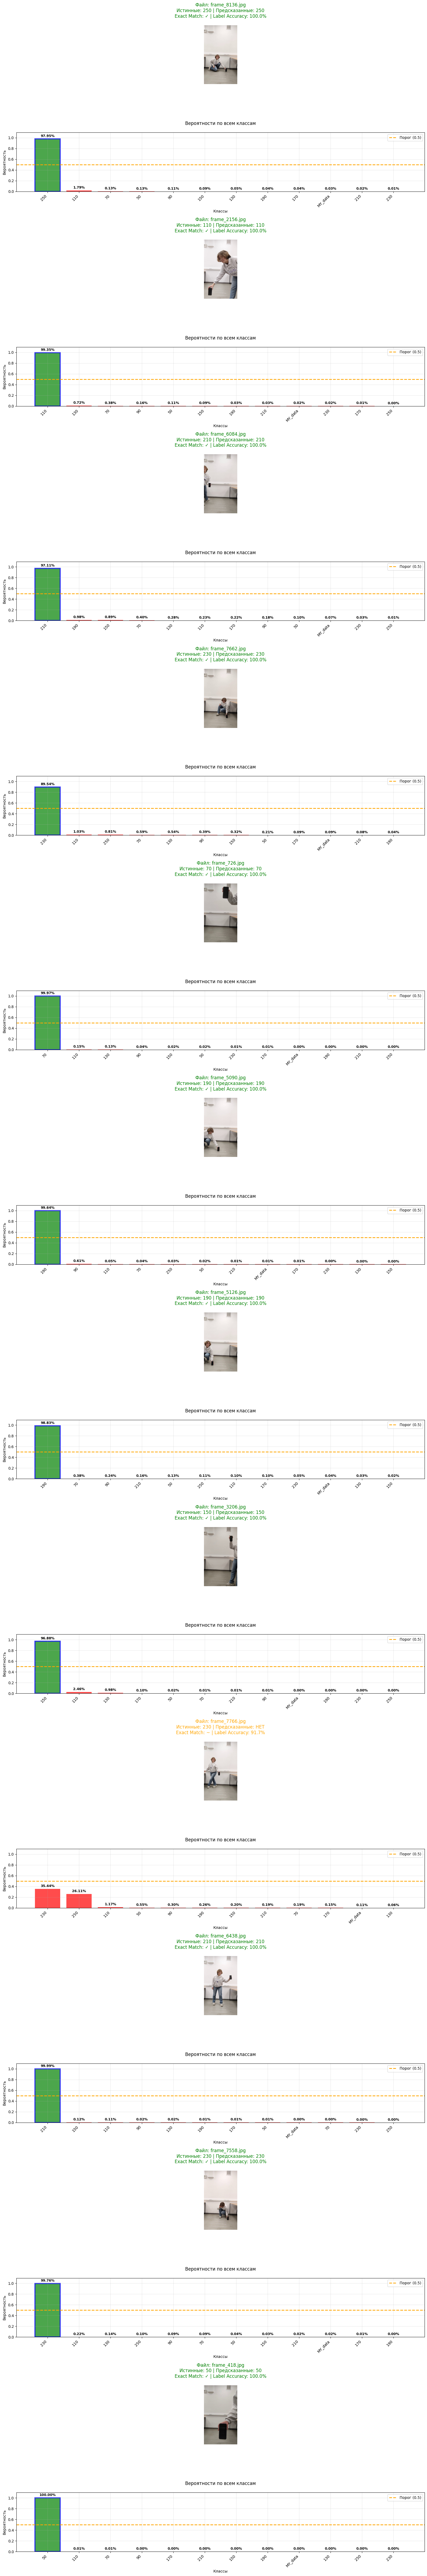

In [ ]:
if __name__ == "__main__":
    try:
        model, class_names, is_multi_label = load_trained_model(
            'phone_fast_created_merged_data_resnet18_multilabel.pth', 
            device=device,
            multi_label=True
        )
        print("Multi-label модель загружена для тестирования")
        print(f"Классы модели: {class_names}")
        
        phone_data_path = "frames"
        
        if not os.path.exists(phone_data_path):
            alternative_paths = [
                "Convolutional-Neural-Network/frames",
                "./Convolutional-Neural-Network/frames", 
                "./frames"
            ]
            
            for path in alternative_paths:
                if os.path.exists(path):
                    phone_data_path = path
                    print(f"Найден путь: {phone_data_path}")
                    break
            else:
                print("Не удалось найти папку phone_data!")
                exit()
        
        print(f"\nЗАПУСК MULTI-LABEL ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ")
        print("=" * 80)
        
        results = predict_multiple_images(
            model=model,
            data_folder=phone_data_path,
            class_names=class_names,
            device=device,
            num_images=20,
            multi_label=is_multi_label,
            threshold=0.5
        )
        
        display_statistics(results, class_names)
        
        if results:
            print(f"\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
            plot_predictions_grid(results, class_names)
        
    except Exception as e:
        print(f"Ошибка при тестировании: {e}")
        traceback.print_exc()